## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

## Michael Hamaty

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Data = "https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv"
df = pd.read_csv(Data)
df


,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


Nice! Clean dataframe

## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [3]:
#we have two options from pandas when we are converting into tidy format, which arre .melt and .wide_to_long
#id_vars used to static column
#var_name for the newcolumn name
#value_name for the new column name for the values
tidy_format =  df.drop(columns="total_litres_of_pure_alcohol").melt(id_vars="country", var_name="drink", value_name="servings")
tidy_format

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217
...,...,...,...
574,Venezuela,wine_servings,3
575,Vietnam,wine_servings,1
576,Yemen,wine_servings,0
577,Zambia,wine_servings,4


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

In [4]:
tidy_format["drink"] = tidy_format["drink"].str.replace("_servings", "", regex=False)
tidy_format

,country,drink,servings
0,Afghanistan,beer,0
1,Albania,beer,89
2,Algeria,beer,25
3,Andorra,beer,245
4,Angola,beer,217
...,...,...,...
574,Venezuela,wine,3
575,Vietnam,wine,1
576,Yemen,wine,0
577,Zambia,wine,4


No Differecne? Maybe I just cant see it

/var/folders/_r/1q92lm0n4hn0yyhhjw8xyy9m0000gn/T/ipykernel_91569/2798424943.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10 = tidy_format.groupby("drink").apply(lambda x: x.nlargest(10, "servings")).reset_index(drop=True)


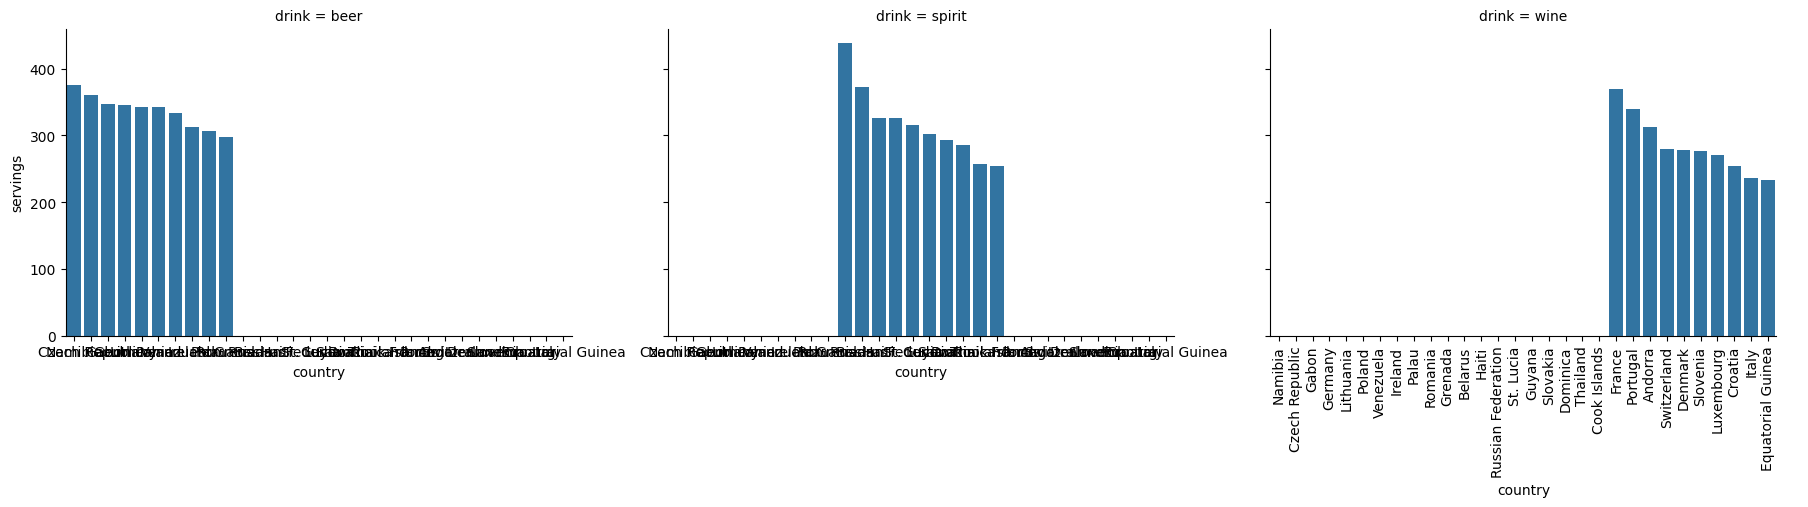

In [ ]:
#first graph -> catplot using col
top10 = tidy_format.groupby("drink").apply(lambda x: x.nlargest(10, "servings")).reset_index(drop=True)

sns.catplot(data=top10, x="country", y="servings", col="drink", kind="bar", height=4, aspect=1.5)
plt.xticks(rotation=90)
plt.show()

/var/folders/_r/1q92lm0n4hn0yyhhjw8xyy9m0000gn/T/ipykernel_91569/97293988.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10 = tidy_format.groupby("drink").apply(lambda x: x.nlargest(10, "servings")).reset_index(drop=True)


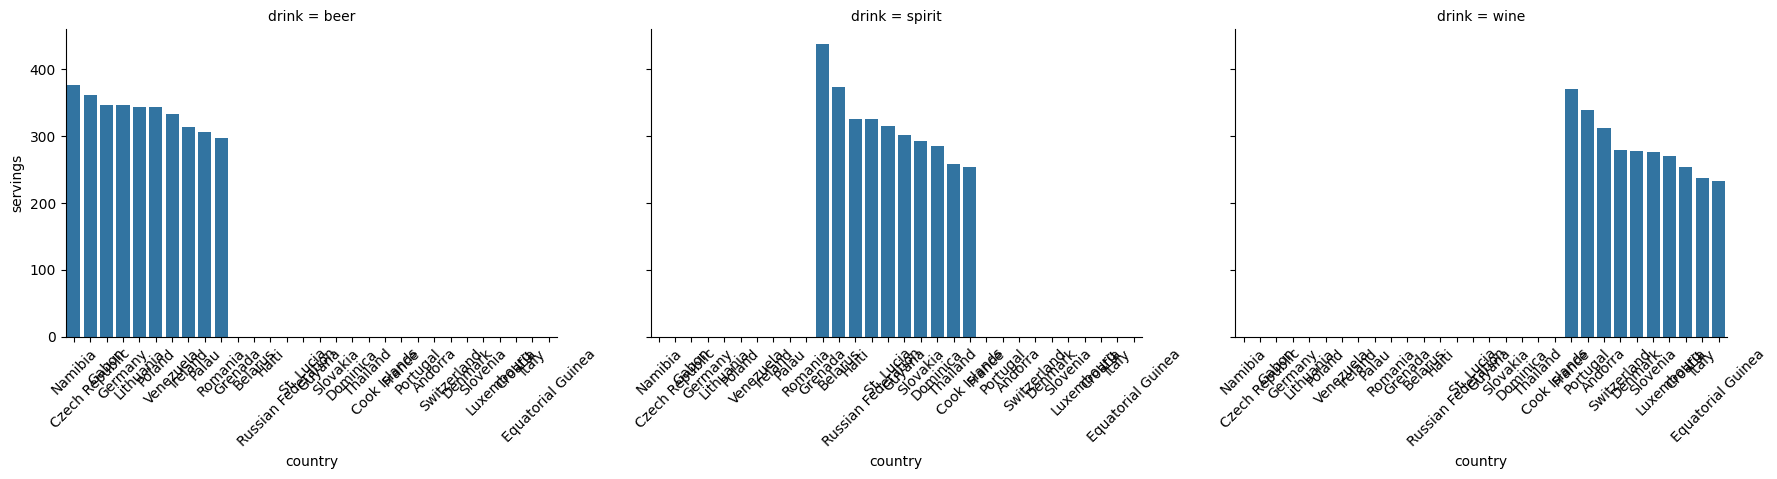

In [9]:
#second -> FacetGrid with map
top10 = tidy_format.groupby("drink").apply(lambda x: x.nlargest(10, "servings")).reset_index(drop=True)

grid = sns.FacetGrid(top10, col="drink", height=4, aspect=1.5)
grid.map_dataframe(sns.barplot, x="country", y="servings")
grid.set_xticklabels(rotation=45)
plt.show()

this facetgrid looks better than the catplot

/var/folders/_r/1q92lm0n4hn0yyhhjw8xyy9m0000gn/T/ipykernel_91569/828194677.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10 = tidy_format.groupby("drink").apply(lambda x: x.nlargest(10, "servings")).reset_index(drop=True)


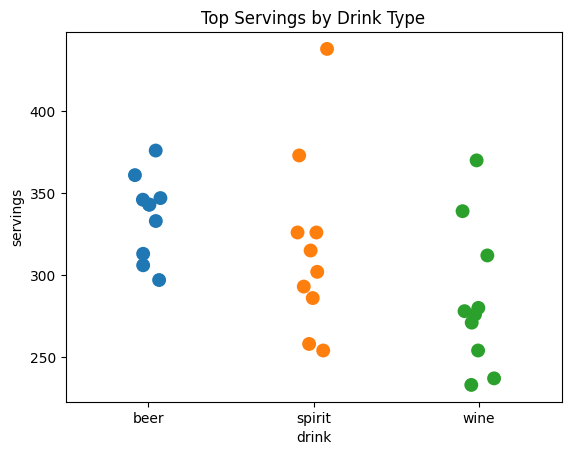

In [ ]:
#third plot -> stripplot attempt for largest drink serivings
top10 = tidy_format.groupby("drink").apply(lambda x: x.nlargest(10, "servings")).reset_index(drop=True)

sns.stripplot(data=top10, x="drink", y="servings", hue="drink", size=10)
plt.title("Top Servings by Drink Type")
plt.show()

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [ ]:
#pivot() -> reshape the df from tidy to wide format
#index=country -> used to select country as row identifiers
#columns=drink -> I had some confusion about this but my best interpretation is its used to spread unque values of the drink column
wide_format = tidy_format.pivot(index="country", columns="drink", values="servings").reset_index()
wide_format.columns.name = None #take off the column header 'drink'
#we dont want country as the index anymore, so we reset it back to a regular column
wide = wide_format.reset_index()
wide

,index,country,beer,spirit,wine
0,0,Afghanistan,0,0,0
1,1,Albania,89,132,54
2,2,Algeria,25,0,14
3,3,Andorra,245,138,312
4,4,Angola,217,57,45
...,...,...,...,...,...
188,188,Venezuela,333,100,3
189,189,Vietnam,111,2,1
190,190,Yemen,6,0,0
191,191,Zambia,32,19,4
